In [1]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader
from torch.utils.data import random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

import seaborn as sns
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


# ***dataset :)***

In [2]:
!unzip "Monkey Species Data .zip"

Archive:  Monkey Species Data .zip
   creating: Monkey Species Data/
   creating: Monkey Species Data/Bald Uakari/
  inflating: Monkey Species Data/Bald Uakari/BU (100).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (1000).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (1001).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (1002).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (1003).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (1004).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (1005).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (1006).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (1007).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (1008).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (1009).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (101).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (1010).jpeg  
  inflating: Monkey Species Data/Bald Uakari/BU (1011).jpeg  
  inflating: Monkey

In [2]:
!ls

'Monkey Species Data'  'Monkey Species Data .zip'   sample_data


In [3]:

dataset = '/content/Monkey Species Data'


In [5]:
class_names = ['Bald Uakari', 'Emperor Tamarin', 'Mandril', 'Proboscis Monkey']

# ***checking image sizes :)***

In [6]:
from PIL import Image
import os


widths = []
heights = []

for class_name in os.listdir(dataset):

    class_folder = os.path.join(dataset, class_name)

    if not os.path.isdir(class_folder):
        continue

    for file in os.listdir(class_folder):

        image_path = os.path.join(class_folder, file)

        try:
            img = Image.open(image_path)

            widths.append(img.size[0])
            heights.append(img.size[1])

        except:
            pass

print("Number of images:", len(widths))
print("Min Width:", min(widths))
print("Max Width:", max(widths))
print("Average Width:", sum(widths)/len(widths))

print("Min Height:", min(heights))
print("Max Height:", max(heights))
print("Average Height:", sum(heights)/len(heights))

Number of images: 4000
Min Width: 100
Max Width: 2048
Average Width: 238.98025
Min Height: 94
Max Height: 3072
Average Height: 207.6195


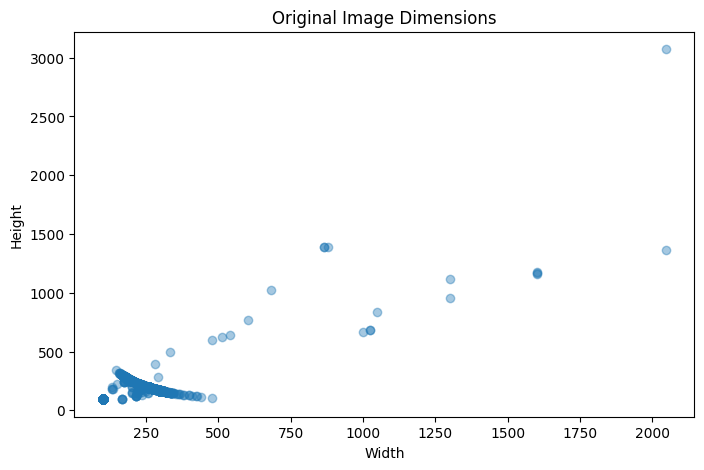

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(widths, heights, alpha=0.4)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Original Image Dimensions")

plt.show()

In [8]:
class_counts = {}

for class_name in os.listdir(dataset):

    class_folder = os.path.join(dataset, class_name)

    if os.path.isdir(class_folder):

        class_counts[class_name] = len(os.listdir(class_folder))

print(class_counts)

{'Bald Uakari': 1000, 'Proboscis Monkey': 1000, 'Emperor Tamarin': 1000, 'Mandril': 1000}


# ***transforming pictures :)***

In [9]:
def get_transform(ArchName, augment=True):
    size = 299 if ArchName == "InceptionV3" else 224
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if augment:
        return transforms.Compose([
            transforms.Resize((size, size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),])
    else:
        return transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),])

# ***splitting data + making the loader funcs :)***

In [10]:
def making_loaders(ArchName, batch_size=32):
    train_tf = get_transform(ArchName, augment=True)
    test_tf  = get_transform(ArchName, augment=False)

    full = datasets.ImageFolder(dataset, transform=train_tf)
    targets = np.array(full.targets)
    indices = np.arange(len(full))

    test_size = 0.15
    val_size  = 0.15

    trainValIndex, testIndex = train_test_split(indices, test_size=test_size,stratify=targets, random_state=42)
    trainIndex, valIndex = train_test_split(trainValIndex,test_size=val_size / (1 - test_size),stratify=targets[trainValIndex],random_state=42)

    print(f"[{ArchName}] Train: {len(trainIndex)} | "
          f"Val: {len(valIndex)} | Test: {len(testIndex)}")

    train_ds = Subset(datasets.ImageFolder(dataset, transform=train_tf), trainIndex)
    val_ds   = Subset(datasets.ImageFolder(dataset, transform=test_tf),  valIndex)
    test_ds  = Subset(datasets.ImageFolder(dataset, transform=test_tf),  testIndex)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader, trainIndex, valIndex, testIndex


# ***defining models :)***

In [11]:
def createModel(ArchName):
    if ArchName == "VGG16":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(4096, 4)

    elif ArchName == "ResNet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, 4)

    elif ArchName == "InceptionV3":
        model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, 4)
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, 4)

    elif ArchName == "MobileNetV2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 4)

    return model.to(device)

# ***training func :)***

In [12]:
def train_model(ArchName, train_loader, val_loader, lr, epochs):
    model     = createModel(ArchName)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_accs, val_accs = [], []
    best_val = 0.0
    best_weights = None

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            loss = nn.CrossEntropyLoss()(outputs, labels)
            loss.backward()
            optimizer.step()
            correct += outputs.argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
        train_acc = correct / total


        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                if isinstance(outputs, tuple):
                    outputs = outputs[0]
                correct += outputs.argmax(1).eq(labels).sum().item()
                total   += labels.size(0)
        val_acc = correct / total

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_acc > best_val:
            best_val     = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f"  Ep {epoch+1:02d}/{epochs} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    model.load_state_dict(best_weights)
    return model, train_accs, val_accs

# ***evaluation func :)***

In [13]:
def evaluation(model, test_loader, ArchName):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            preds = outputs.argmax(1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)


    print(f"  {ArchName} Test Results <3")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix of {ArchName}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

    return acc, prec, rec, f1

# ***Learning curve :)***

In [14]:
def LearningCurve(train_accs, val_accs, ArchName, combo_label):
    epochs = range(1, len(train_accs) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_accs, 'b-o', label='Train Accuracy')
    plt.plot(epochs, val_accs, 'r-o', label='Val Accuracy')
    plt.title(f'{ArchName}  Learning Curve\n{combo_label}')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()

# ***hyperparameter combos :)***

In [15]:
hyperparameters = [
    {'lr': 0.001,   'epochs': 15},
    {'lr': 0.0001,  'epochs': 12},
    {'lr': 0.00001, 'epochs': 20},]

architechtures = ["VGG16", "ResNet50", "InceptionV3", "MobileNetV2"]

# ***training models :)***

 VGG16
-------------------------------------------------------
[VGG16] Train: 2800 | Val: 600 | Test: 600

  Combo 1: lr=0.001, epochs=15
  Ep 01/15 | Train: 0.2629 | Val: 0.2500
  Ep 02/15 | Train: 0.2746 | Val: 0.2100
  Ep 03/15 | Train: 0.2500 | Val: 0.2500
  Ep 04/15 | Train: 0.2457 | Val: 0.2500
  Ep 05/15 | Train: 0.2414 | Val: 0.2500
  Ep 06/15 | Train: 0.2371 | Val: 0.2500
  Ep 07/15 | Train: 0.2450 | Val: 0.2500
  Ep 08/15 | Train: 0.2389 | Val: 0.2500
  Ep 09/15 | Train: 0.2446 | Val: 0.2500
  Ep 10/15 | Train: 0.2468 | Val: 0.2500
  Ep 11/15 | Train: 0.2314 | Val: 0.2500
  Ep 12/15 | Train: 0.2575 | Val: 0.2500
  Ep 13/15 | Train: 0.2436 | Val: 0.2500
  Ep 14/15 | Train: 0.2439 | Val: 0.2500
  Ep 15/15 | Train: 0.2336 | Val: 0.2500
  → Final Train: 0.2336 | Final Val: 0.2500

  Combo 2: lr=0.0001, epochs=12
  Ep 01/12 | Train: 0.9200 | Val: 0.9750
  Ep 02/12 | Train: 0.9843 | Val: 0.9733
  Ep 03/12 | Train: 0.9782 | Val: 0.9617
  Ep 04/12 | Train: 0.9825 | Val: 0.9717
  Ep 0

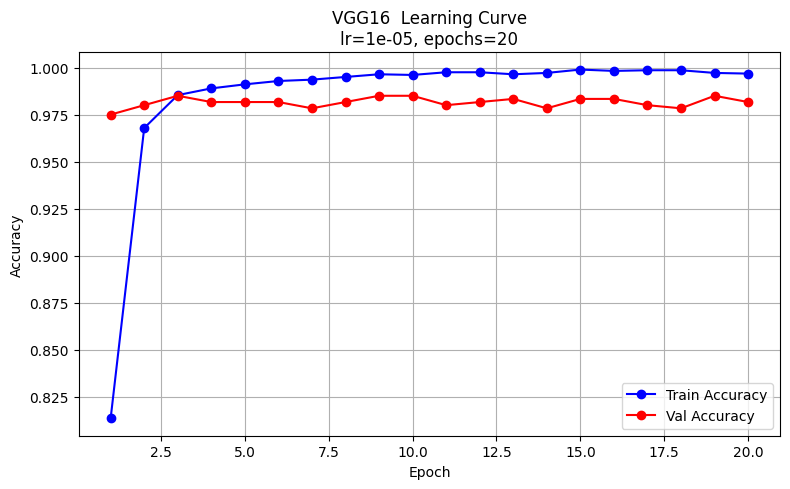

 ResNet50
-------------------------------------------------------
[ResNet50] Train: 2800 | Val: 600 | Test: 600

  Combo 1: lr=0.001, epochs=15
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


  Ep 01/15 | Train: 0.9150 | Val: 0.8933
  Ep 02/15 | Train: 0.9421 | Val: 0.9617
  Ep 03/15 | Train: 0.9650 | Val: 0.9583
  Ep 04/15 | Train: 0.9618 | Val: 0.9533
  Ep 05/15 | Train: 0.9671 | Val: 0.9667
  Ep 06/15 | Train: 0.9779 | Val: 0.9567
  Ep 07/15 | Train: 0.9664 | Val: 0.9617
  Ep 08/15 | Train: 0.9732 | Val: 0.9683
  Ep 09/15 | Train: 0.9829 | Val: 0.9533
  Ep 10/15 | Train: 0.9818 | Val: 0.9550
  Ep 11/15 | Train: 0.9857 | Val: 0.9683
  Ep 12/15 | Train: 0.9886 | Val: 0.9433
  Ep 13/15 | Train: 0.9818 | Val: 0.9533
  Ep 14/15 | Train: 0.9896 | Val: 0.9633
  Ep 15/15 | Train: 0.9886 | Val: 0.9633
  → Final Train: 0.9886 | Final Val: 0.9633

  Combo 2: lr=0.0001, epochs=12
  Ep 01/12 | Train: 0.9311 | Val: 0.9833
  Ep 02/12 | Train: 0.9868 | Val: 0.9867
  Ep 03/12 | Train: 0.9904 | Val: 0.9867
  Ep 04/12 | Train: 0.9939 | Val: 0.9817
  Ep 05/12 | Train: 0.9954 | Val: 0.9783
  Ep 06/12 | Train: 0.9932 | Val: 0.9817
  Ep 07/12 | Train: 0.9957 | Val: 0.9867
  Ep 08/12 | Train: 0

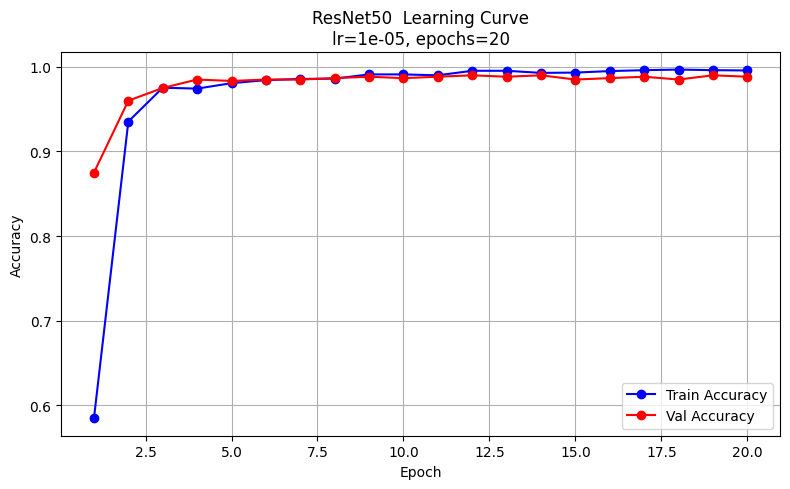

 InceptionV3
-------------------------------------------------------
[InceptionV3] Train: 2800 | Val: 600 | Test: 600

  Combo 1: lr=0.001, epochs=15
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 139MB/s] 


  Ep 01/15 | Train: 0.8314 | Val: 0.8617
  Ep 02/15 | Train: 0.8871 | Val: 0.9383
  Ep 03/15 | Train: 0.9132 | Val: 0.9267
  Ep 04/15 | Train: 0.9386 | Val: 0.9500
  Ep 05/15 | Train: 0.9464 | Val: 0.9267
  Ep 06/15 | Train: 0.9418 | Val: 0.9367
  Ep 07/15 | Train: 0.9543 | Val: 0.9683
  Ep 08/15 | Train: 0.9482 | Val: 0.9383
  Ep 09/15 | Train: 0.9586 | Val: 0.8733
  Ep 10/15 | Train: 0.9639 | Val: 0.9467
  Ep 11/15 | Train: 0.9746 | Val: 0.8767
  Ep 12/15 | Train: 0.9557 | Val: 0.9317
  Ep 13/15 | Train: 0.9614 | Val: 0.9150
  Ep 14/15 | Train: 0.9571 | Val: 0.9500
  Ep 15/15 | Train: 0.9711 | Val: 0.9100
  → Final Train: 0.9711 | Final Val: 0.9100

  Combo 2: lr=0.0001, epochs=12
  Ep 01/12 | Train: 0.9368 | Val: 0.9767
  Ep 02/12 | Train: 0.9811 | Val: 0.9750
  Ep 03/12 | Train: 0.9850 | Val: 0.9733
  Ep 04/12 | Train: 0.9854 | Val: 0.9667
  Ep 05/12 | Train: 0.9871 | Val: 0.9700
  Ep 06/12 | Train: 0.9875 | Val: 0.9783
  Ep 07/12 | Train: 0.9907 | Val: 0.9783
  Ep 08/12 | Train: 0

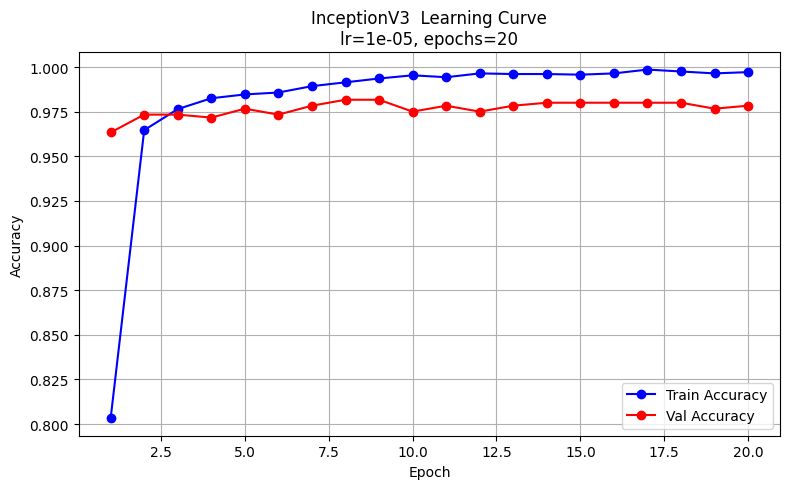

 MobileNetV2
-------------------------------------------------------
[MobileNetV2] Train: 2800 | Val: 600 | Test: 600

  Combo 1: lr=0.001, epochs=15
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 173MB/s]


  Ep 01/15 | Train: 0.9261 | Val: 0.9717
  Ep 02/15 | Train: 0.9664 | Val: 0.9650
  Ep 03/15 | Train: 0.9682 | Val: 0.9750
  Ep 04/15 | Train: 0.9679 | Val: 0.9633
  Ep 05/15 | Train: 0.9839 | Val: 0.9667
  Ep 06/15 | Train: 0.9757 | Val: 0.9733
  Ep 07/15 | Train: 0.9818 | Val: 0.9667
  Ep 08/15 | Train: 0.9879 | Val: 0.9650
  Ep 09/15 | Train: 0.9868 | Val: 0.9667
  Ep 10/15 | Train: 0.9804 | Val: 0.9633
  Ep 11/15 | Train: 0.9818 | Val: 0.9533
  Ep 12/15 | Train: 0.9896 | Val: 0.9667
  Ep 13/15 | Train: 0.9850 | Val: 0.9433
  Ep 14/15 | Train: 0.9882 | Val: 0.9800
  Ep 15/15 | Train: 0.9907 | Val: 0.9717
  → Final Train: 0.9907 | Final Val: 0.9717

  Combo 2: lr=0.0001, epochs=12
  Ep 01/12 | Train: 0.8761 | Val: 0.9750
  Ep 02/12 | Train: 0.9761 | Val: 0.9767
  Ep 03/12 | Train: 0.9832 | Val: 0.9817
  Ep 04/12 | Train: 0.9886 | Val: 0.9800
  Ep 05/12 | Train: 0.9943 | Val: 0.9817
  Ep 06/12 | Train: 0.9932 | Val: 0.9783
  Ep 07/12 | Train: 0.9929 | Val: 0.9833
  Ep 08/12 | Train: 0

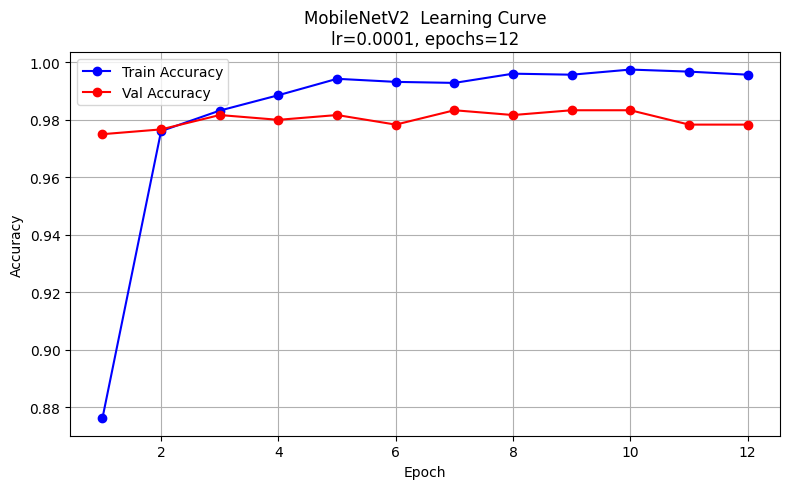

In [16]:
all_results  = {}
best_models  = {}

for arch in architechtures:
    print(f" {arch}")
    print(f"{'-'*55}")

    batch_size = 16 if arch == "InceptionV3" else 32
    train_loader, val_loader, test_loader, train_idx, val_idx, test_idx = \
        making_loaders(arch, batch_size)


    combo_results = []
    best_val_for_arch = 0.0

    for i, hp in enumerate(hyperparameters):
        print(f"\n  Combo {i+1}: lr={hp['lr']}, epochs={hp['epochs']}")

        model, train_accs, val_accs = train_model(arch, train_loader, val_loader, hp['lr'], hp['epochs'])

        final_train = train_accs[-1]
        final_val   = val_accs[-1]

        combo_results.append({
            'lr': hp['lr'], 'epochs': hp['epochs'],
            'train_acc': final_train, 'val_acc': final_val,
            'train_accs': train_accs, 'val_accs': val_accs,
            'model': model})

        print(f"  → Final Train: {final_train:.4f} | Final Val: {final_val:.4f}")

        if final_val > best_val_for_arch:
            best_val_for_arch = final_val
            best_models[arch] = (model, hp['lr'], hp['epochs'], test_loader)

    all_results[arch] = combo_results

    best_combo = max(combo_results, key=lambda x: x['val_acc'])
    combo = f"lr={best_combo['lr']}, epochs={best_combo['epochs']}"
    LearningCurve(best_combo['train_accs'], best_combo['val_accs'], arch, combo)



In [17]:
print("TABLE 3: Hyperparameter Combinations and Performance :) ")
print("="*70)
for arch in architechtures:
    print(f"\n{arch}:")
    print(f"  {'#':<4} {'LR':<10} {'Epochs':<8} {'Train Acc':<12} {'Val Acc'}")
    for j, r in enumerate(all_results[arch], 1):
        print(f"  {j:<4} {r['lr']:<10} {r['epochs']:<8} "
              f"{r['train_acc']:.4f}  {r['val_acc']:.4f}")

TABLE 3: Hyperparameter Combinations and Performance :) 

VGG16:
  #    LR         Epochs   Train Acc    Val Acc
  1    0.001      15       0.2336  0.2500
  2    0.0001     12       0.9932  0.9800
  3    1e-05      20       0.9968  0.9817

ResNet50:
  #    LR         Epochs   Train Acc    Val Acc
  1    0.001      15       0.9886  0.9633
  2    0.0001     12       0.9986  0.9783
  3    1e-05      20       0.9957  0.9883

InceptionV3:
  #    LR         Epochs   Train Acc    Val Acc
  1    0.001      15       0.9711  0.9100
  2    0.0001     12       0.9954  0.9750
  3    1e-05      20       0.9971  0.9783

MobileNetV2:
  #    LR         Epochs   Train Acc    Val Acc
  1    0.001      15       0.9907  0.9717
  2    0.0001     12       0.9957  0.9783
  3    1e-05      20       0.9857  0.9767


TABLE 4: Test Set Results, Best Model per Architecture :)
  VGG16 Test Results <3
  Accuracy : 0.9883
  Precision: 0.9884
  Recall   : 0.9883
  F1-Score : 0.9883


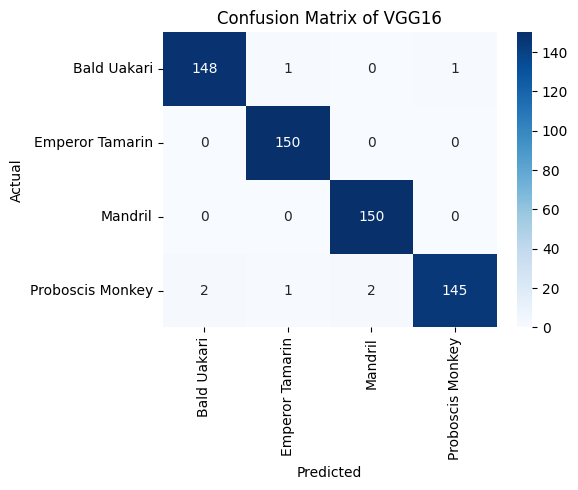

  ResNet50 Test Results <3
  Accuracy : 0.9850
  Precision: 0.9850
  Recall   : 0.9850
  F1-Score : 0.9850


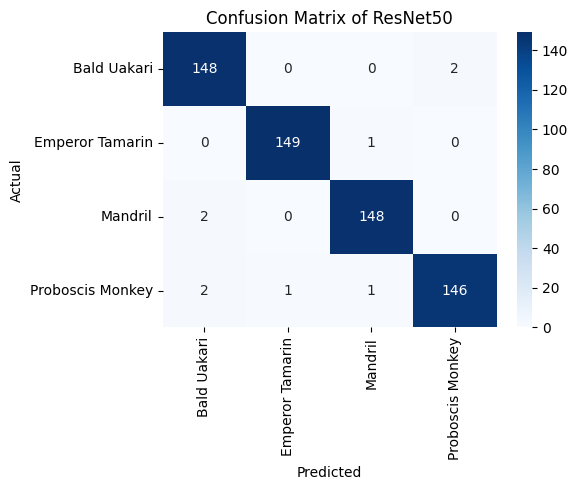

  InceptionV3 Test Results <3
  Accuracy : 0.9883
  Precision: 0.9883
  Recall   : 0.9883
  F1-Score : 0.9883


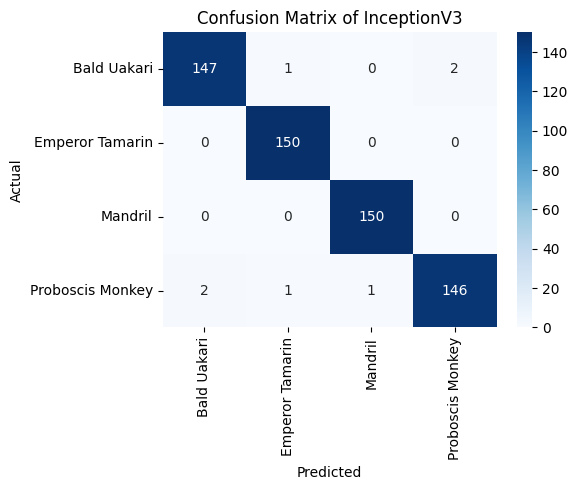

  MobileNetV2 Test Results <3
  Accuracy : 0.9833
  Precision: 0.9834
  Recall   : 0.9833
  F1-Score : 0.9833


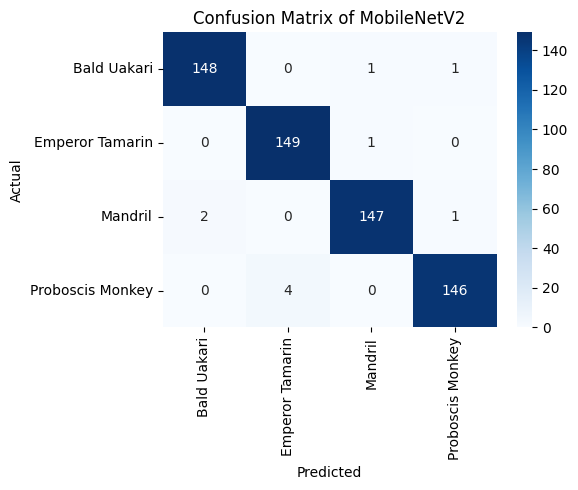


Architecture    Accuracy     Precision    Recall       F1-Score
----------------------------------------------------------
VGG16           0.9883       0.9884       0.9883       0.9883
ResNet50        0.9850       0.9850       0.9850       0.9850
InceptionV3     0.9883       0.9883       0.9883       0.9883
MobileNetV2     0.9833       0.9834       0.9833       0.9833


In [18]:
print("TABLE 4: Test Set Results, Best Model per Architecture :)")
print("="*65)

test_results = {}
for arch in architechtures:
    model, best_lr, best_epochs, test_loader = best_models[arch]
    acc, prec, rec, f1 = evaluation(model, test_loader, arch)
    test_results[arch] = {
        'acc': acc, 'prec': prec,
        'rec': rec, 'f1':   f1}

print(f"\n{'Architecture':<15} {'Accuracy':<12} {'Precision':<12} "
      f"{'Recall':<12} {'F1-Score'}")
print("-"*58)
for arch in architechtures:
    r = test_results[arch]
    print(f"{arch:<15} {r['acc']:<12.4f} {r['prec']:<12.4f} "
          f"{r['rec']:<12.4f} {r['f1']:.4f}")

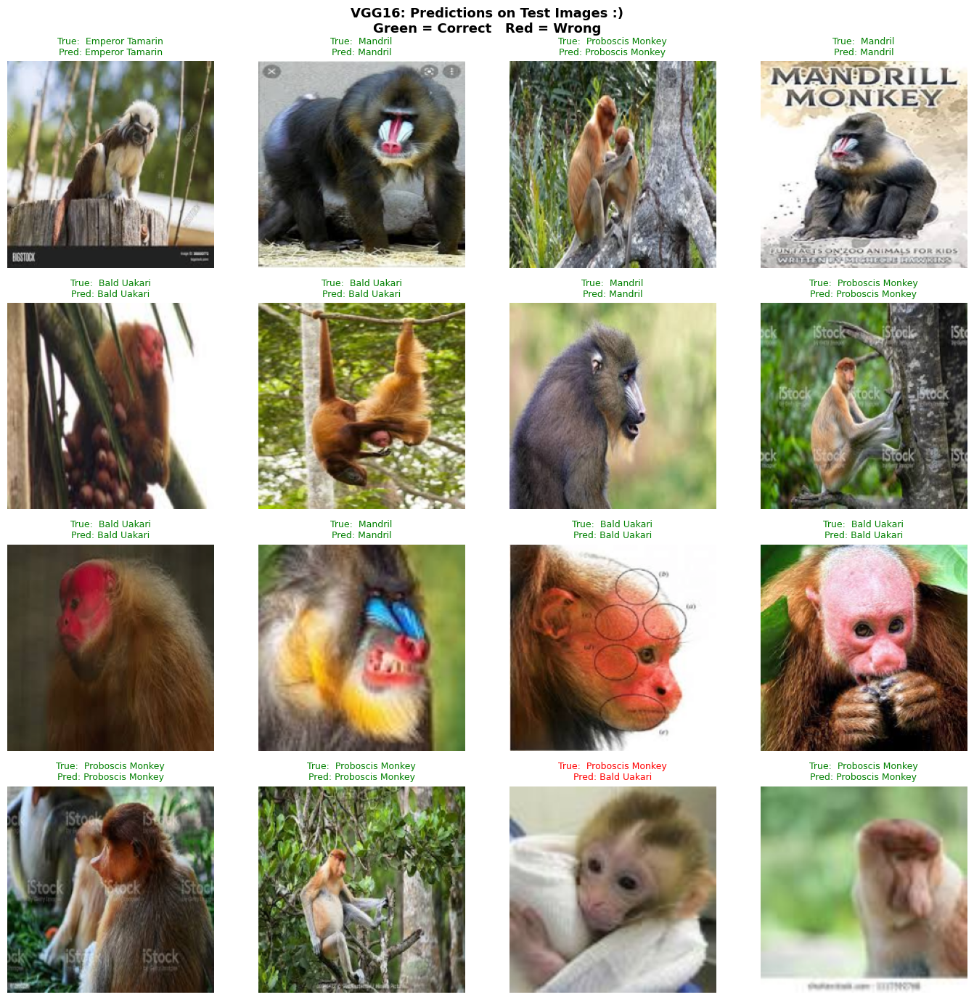

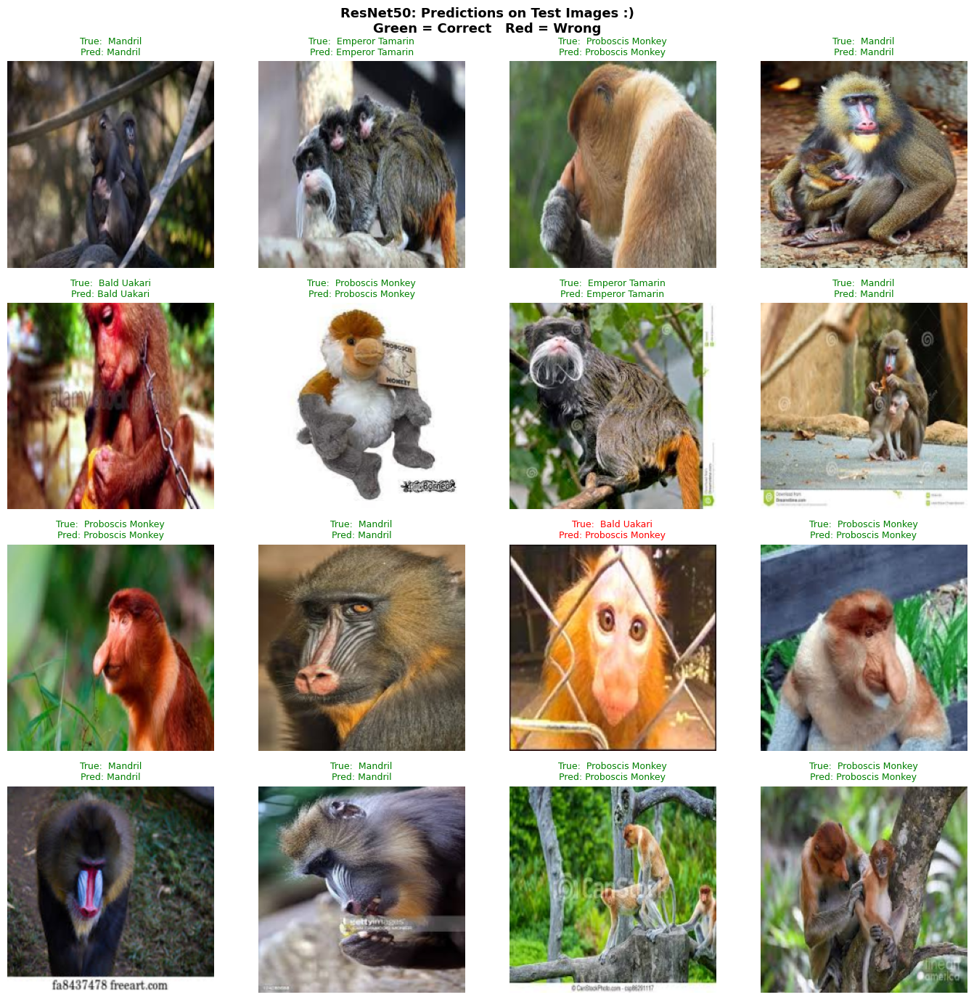

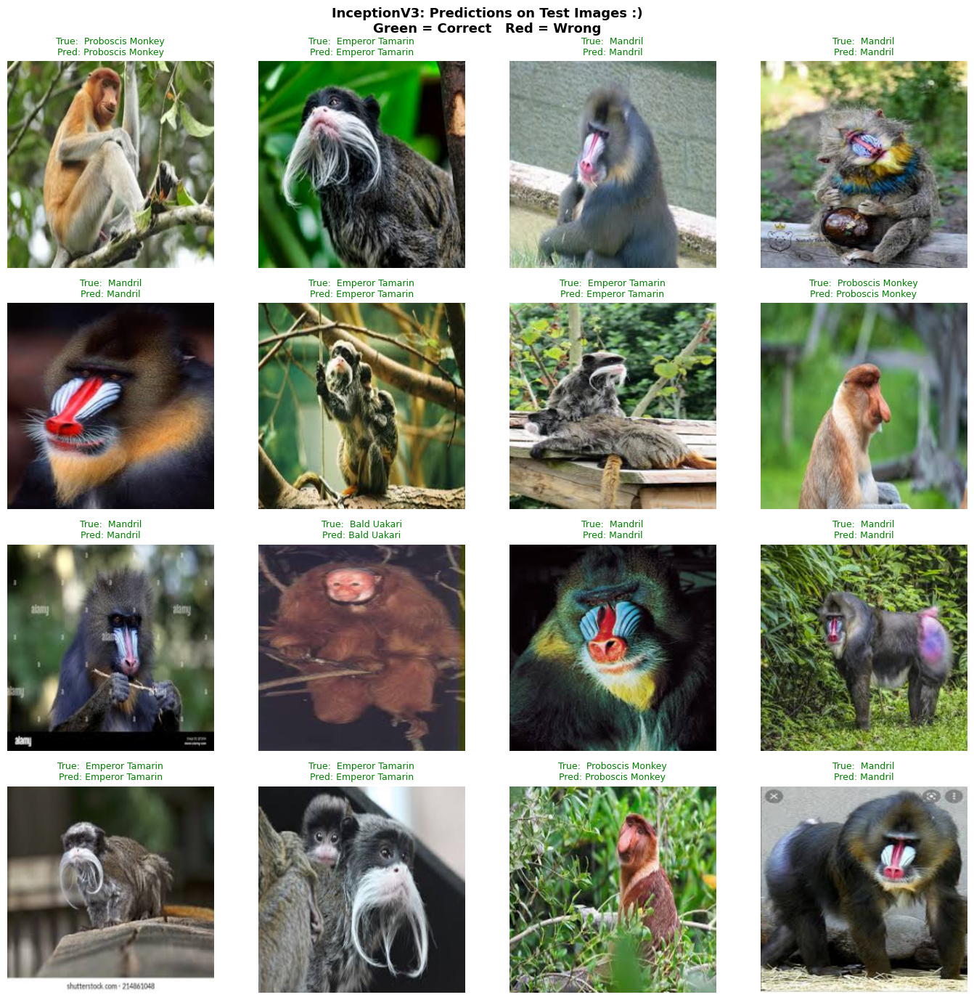

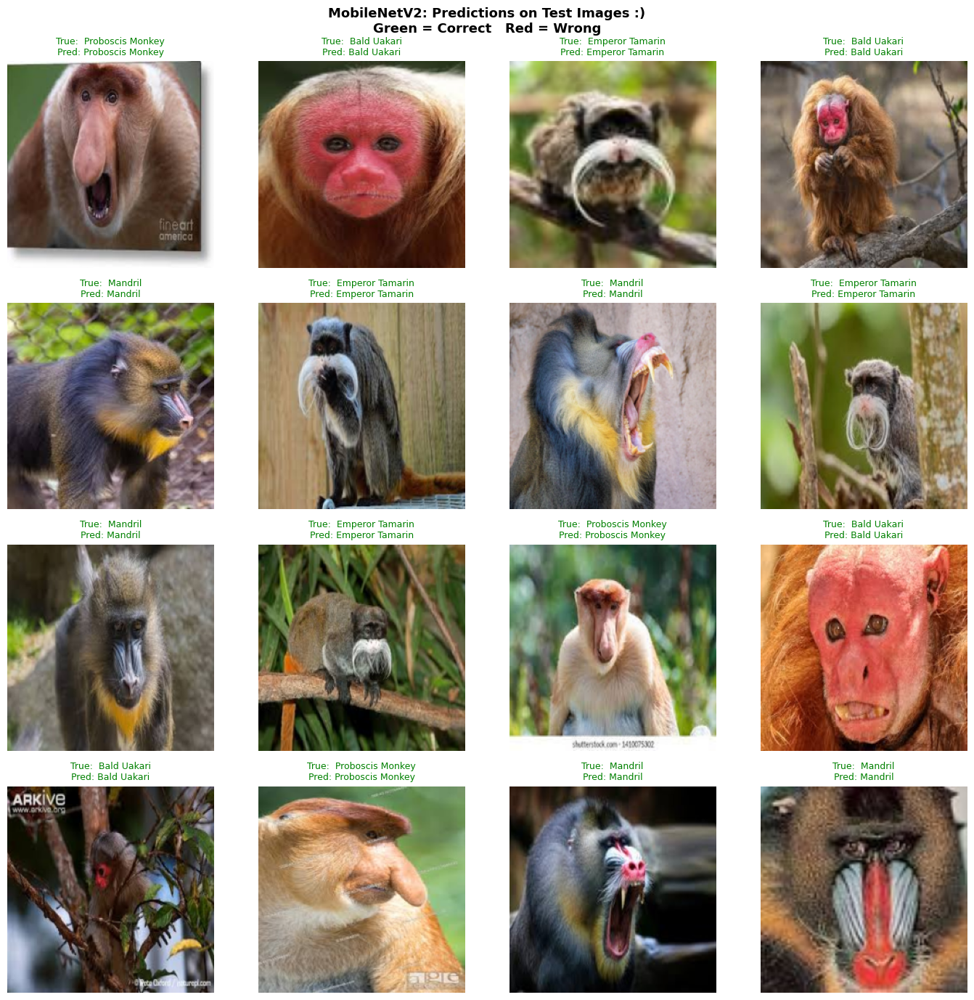

In [28]:
import random
from torchvision import datasets
from torch.utils.data import Subset

def show_predictions(model, ArchName, num_images=16):

    test_tf  = get_transform(ArchName, augment=False)
    test_ds_full = datasets.ImageFolder(dataset, transform=test_tf)

    targets  = np.array(test_ds_full.targets)
    indices  = np.arange(len(test_ds_full))
    _, testIndex = train_test_split(indices, test_size=0.15,stratify=targets, random_state=42)
    test_ds = Subset(test_ds_full, testIndex)


    pickRandm = random.sample(range(len(test_ds)), num_images)

    model.eval()
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    axes = axes.flatten()

    for i, index in enumerate(pickRandm):
        image_tensor, true_label = test_ds[index]


        with torch.no_grad():
            output = model(image_tensor.unsqueeze(0).to(device))
            if isinstance(output, tuple):
                output = output[0]
            pred_label = output.argmax(1).item()


        img = image_tensor.clone()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img  = img * std + mean
        img  = img.permute(1, 2, 0).numpy()
        img  = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].axis('off')

        true_name = class_names[true_label]
        pred_name = class_names[pred_label]


        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title( f"True:  {true_name}\nPred: {pred_name}",color=color, fontsize=9)

    plt.suptitle(f'{ArchName}: Predictions on Test Images :)\n'f'Green = Correct   Red = Wrong',fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

for arch in architechtures:
    model, best_lr, best_epochs, test_loader = best_models[arch]
    show_predictions(model, arch, num_images=16)